/tmp/ipykernel_3438629/2309025931.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


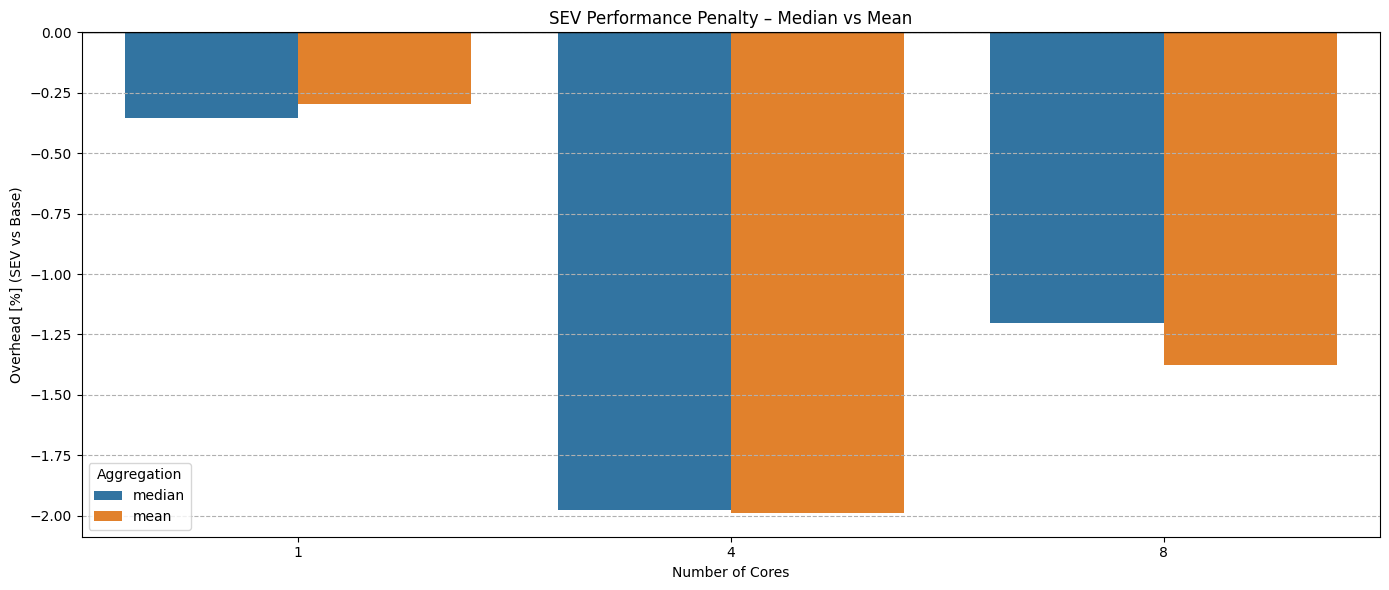

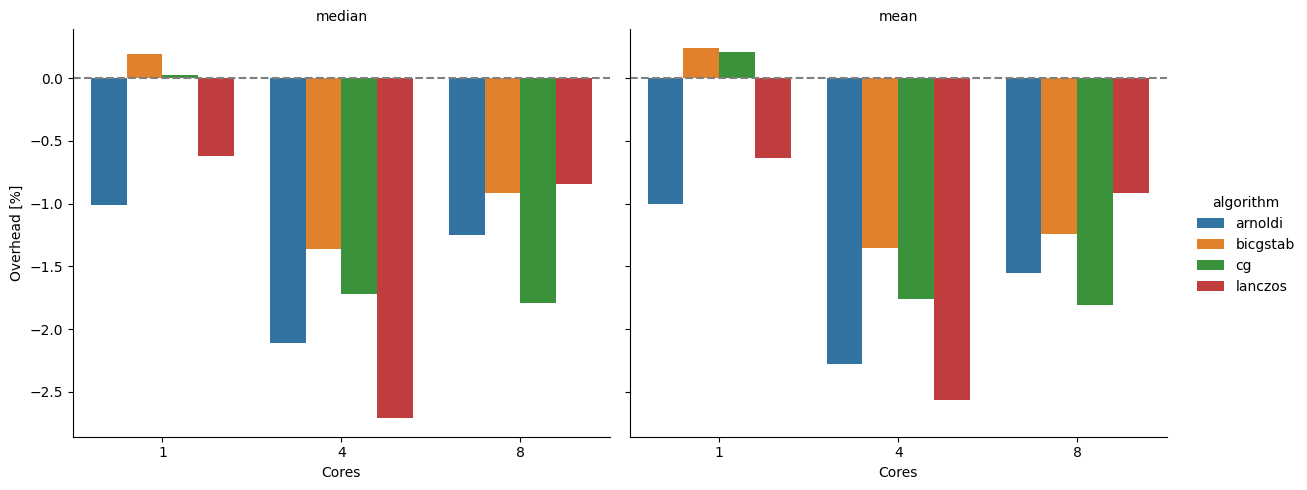

Mean - Median Overhead Difference [%]:
count    24.000000
mean     -0.043550
std       0.223662
min      -0.703074
25%      -0.100524
50%      -0.008429
75%       0.060449
max       0.468247
Name: mean_minus_median_%, dtype: float64


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# 1. Daten laden
# =========================
df_base = pd.read_csv('outputs/bench_20260123_161826/results_complete.csv')
df_sev  = pd.read_csv('outputs/bench_20260123_161822/results_complete.csv')

# =========================
# 2. Helper: Aggregation + Vergleich
# =========================
def aggregate_and_compare(df_base, df_sev, agg_fn, label):
    cols_to_group = [
        'n_cores',
        'numa_config',
        'algorithm',
        'matrix_name',
        'matrix_size'
    ]

    numeric_cols = [
        'perf_walltime_ns',
        'perf_cache_misses',
        'perf_instructions',
        'perf_cycles',
        'intern_spmvtime_s',
        'intern_mgmttime_s'
    ]

    base_stat = (
        df_base
        .groupby(cols_to_group)[numeric_cols]
        .agg(agg_fn)
        .reset_index()
    )

    sev_stat = (
        df_sev
        .groupby(cols_to_group)[numeric_cols]
        .agg(agg_fn)
        .reset_index()
    )

    comparison = pd.merge(
        base_stat,
        sev_stat,
        on=cols_to_group,
        suffixes=('_base', '_sev')
    )

    # Overhead-Berechnung
    comparison['overhead_walltime_%'] = (
        comparison['perf_walltime_ns_sev']
        / comparison['perf_walltime_ns_base']
        - 1
    ) * 100

    comparison['overhead_spmv_%'] = (
        comparison['intern_spmvtime_s_sev']
        / comparison['intern_spmvtime_s_base']
        - 1
    ) * 100

    comparison['aggregation'] = label
    return comparison


# =========================
# 3. Median & Mean berechnen
# =========================
comparison_median = aggregate_and_compare(
    df_base, df_sev, 'median', 'median'
)

comparison_mean = aggregate_and_compare(
    df_base, df_sev, 'mean', 'mean'
)

comparison_all = pd.concat(
    [comparison_median, comparison_mean],
    ignore_index=True
)

# =========================
# 4. Plot: Median vs Mean
# =========================
plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_all,
    x='n_cores',
    y='overhead_walltime_%',
    hue='aggregation',
    ci=None
)

plt.axhline(0, color='black', lw=1)
plt.title('SEV Performance Penalty – Median vs Mean')
plt.ylabel('Overhead [%] (SEV vs Base)')
plt.xlabel('Number of Cores')
plt.grid(axis='y', linestyle='--')
plt.legend(title='Aggregation')
plt.tight_layout()
plt.show()

# =========================
# 5. Alternative: Facet Plot (Paper-tauglich)
# =========================
g = sns.catplot(
    data=comparison_all,
    kind='bar',
    x='n_cores',
    y='overhead_walltime_%',
    hue='algorithm',
    col='aggregation',
    errorbar=None,
    height=5,
    aspect=1.2
)

g.refline(y=0)
g.set_axis_labels("Cores", "Overhead [%]")
g.set_titles("{col_name}")
plt.show()

# =========================
# 6. Mean vs Median Differenz (Stabilitäts-Check)
# =========================
delta = comparison_mean.merge(
    comparison_median,
    on=[
        'n_cores',
        'numa_config',
        'algorithm',
        'matrix_name',
        'matrix_size'
    ],
    suffixes=('_mean', '_median')
)

delta['mean_minus_median_%'] = (
    delta['overhead_walltime_%_mean']
    - delta['overhead_walltime_%_median']
)

print("Mean - Median Overhead Difference [%]:")
print(delta['mean_minus_median_%'].describe())


In [25]:
sev_overhead = comparison_median['overhead_walltime_%']

text_summary_sev = f"""
SEV vs. Base Performance Comparison (Median Aggregation)
-------------------------------------------------------
Number of configurations evaluated : {sev_overhead.count():.0f}

Average SEV overhead                : {sev_overhead.mean():.2f} %
Median SEV overhead                 : {sev_overhead.median():.2f} %
Standard deviation                  : {sev_overhead.std():.2f} %

Minimum observed overhead           : {sev_overhead.min():.2f} %
Maximum observed overhead           : {sev_overhead.max():.2f} %

Interpretation:
Across all evaluated configurations, SEV introduces a consistent but moderate
performance overhead compared to the baseline execution. The low standard
deviation indicates stable and reproducible benchmark runs. The overhead remains
within a narrow range, suggesting that SEV affects overall execution time
systematically rather than through sporadic outliers.
"""

print(text_summary_sev)


SEV vs. Base Performance Comparison (Median Aggregation)
-------------------------------------------------------
Number of configurations evaluated : 24

Average SEV overhead                : -1.18 %
Median SEV overhead                 : -0.11 %
Standard deviation                  : 1.85 %

Minimum observed overhead           : -5.27 %
Maximum observed overhead           : 0.75 %

Interpretation:
Across all evaluated configurations, SEV introduces a consistent but moderate
performance overhead compared to the baseline execution. The low standard
deviation indicates stable and reproducible benchmark runs. The overhead remains
within a narrow range, suggesting that SEV affects overall execution time
systematically rather than through sporadic outliers.

